# [LAB-06] 11. 100% Stacked Bar Plot

## #01. 준비작업

### 1. 패키지 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import pivot_table
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기

In [2]:
origin = load_data("region_jobs")
origin

📚 지역별 산업 종사자 수를 조사한 가상의 데이터


,지역,산업,종사자 수
0,서울,서비스업,520
1,부산,서비스업,340
2,대구,서비스업,280
3,인천,서비스업,310
4,서울,제조업,180
5,부산,제조업,220
6,대구,제조업,160
7,인천,제조업,140
8,서울,IT산업,260
9,부산,IT산업,110


### 3. 데이터 전처리 (1) - 피벗 테이블 구성

In [3]:
# # 데이터 피벗팅 (fill_value=0 --> 결측치를 0으로 채움)
df = pivot_table(origin, index="지역", columns="산업", 
                 values="종사자 수", aggfunc=np.sum, fill_value=0)

# 인덱스를 문자열 카테고리로 변환
df.index = df.index.astype('str').astype('category')

df

/var/folders/yd/ms1f950j3h349tw8w7kx8g2m0000gn/T/ipykernel_3217/3582114666.py:2: FutureWarning: The provided callable <function sum at 0x10af0c220> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pivot_table(origin, index="지역", columns="산업",


산업,IT산업,서비스업,제조업
지역,,,
대구,90,280,160
부산,110,340,220
서울,260,520,180
인천,150,310,140


### 4. 데이터 전처리 (2) - 절대값을 백분율로 변경하기 위해 총 합계 구하기

In [4]:
df['sum'] = df.sum(axis=1)
df

산업,IT산업,서비스업,제조업,sum
지역,,,,
대구,90,280,160,530
부산,110,340,220,670
서울,260,520,180,960
인천,150,310,140,600


### 5. 데이터 전처리 (3) - 각 컬럼의 값을 백분율로 변환하고 총 합계 제거

In [5]:
for col in df.columns:
    df[col] = df[col] / df['sum'] * 100

df.drop('sum', axis=1, inplace=True)
df

산업,IT산업,서비스업,제조업
지역,,,
대구,16.981,52.830,30.189
부산,16.418,50.746,32.836
서울,27.083,54.167,18.750
인천,25.000,51.667,23.333


## #02. 분할 막대 그래프

- 기본적으로 누적 막대 그래프에서 데이터셋만 변경된 형태이다.

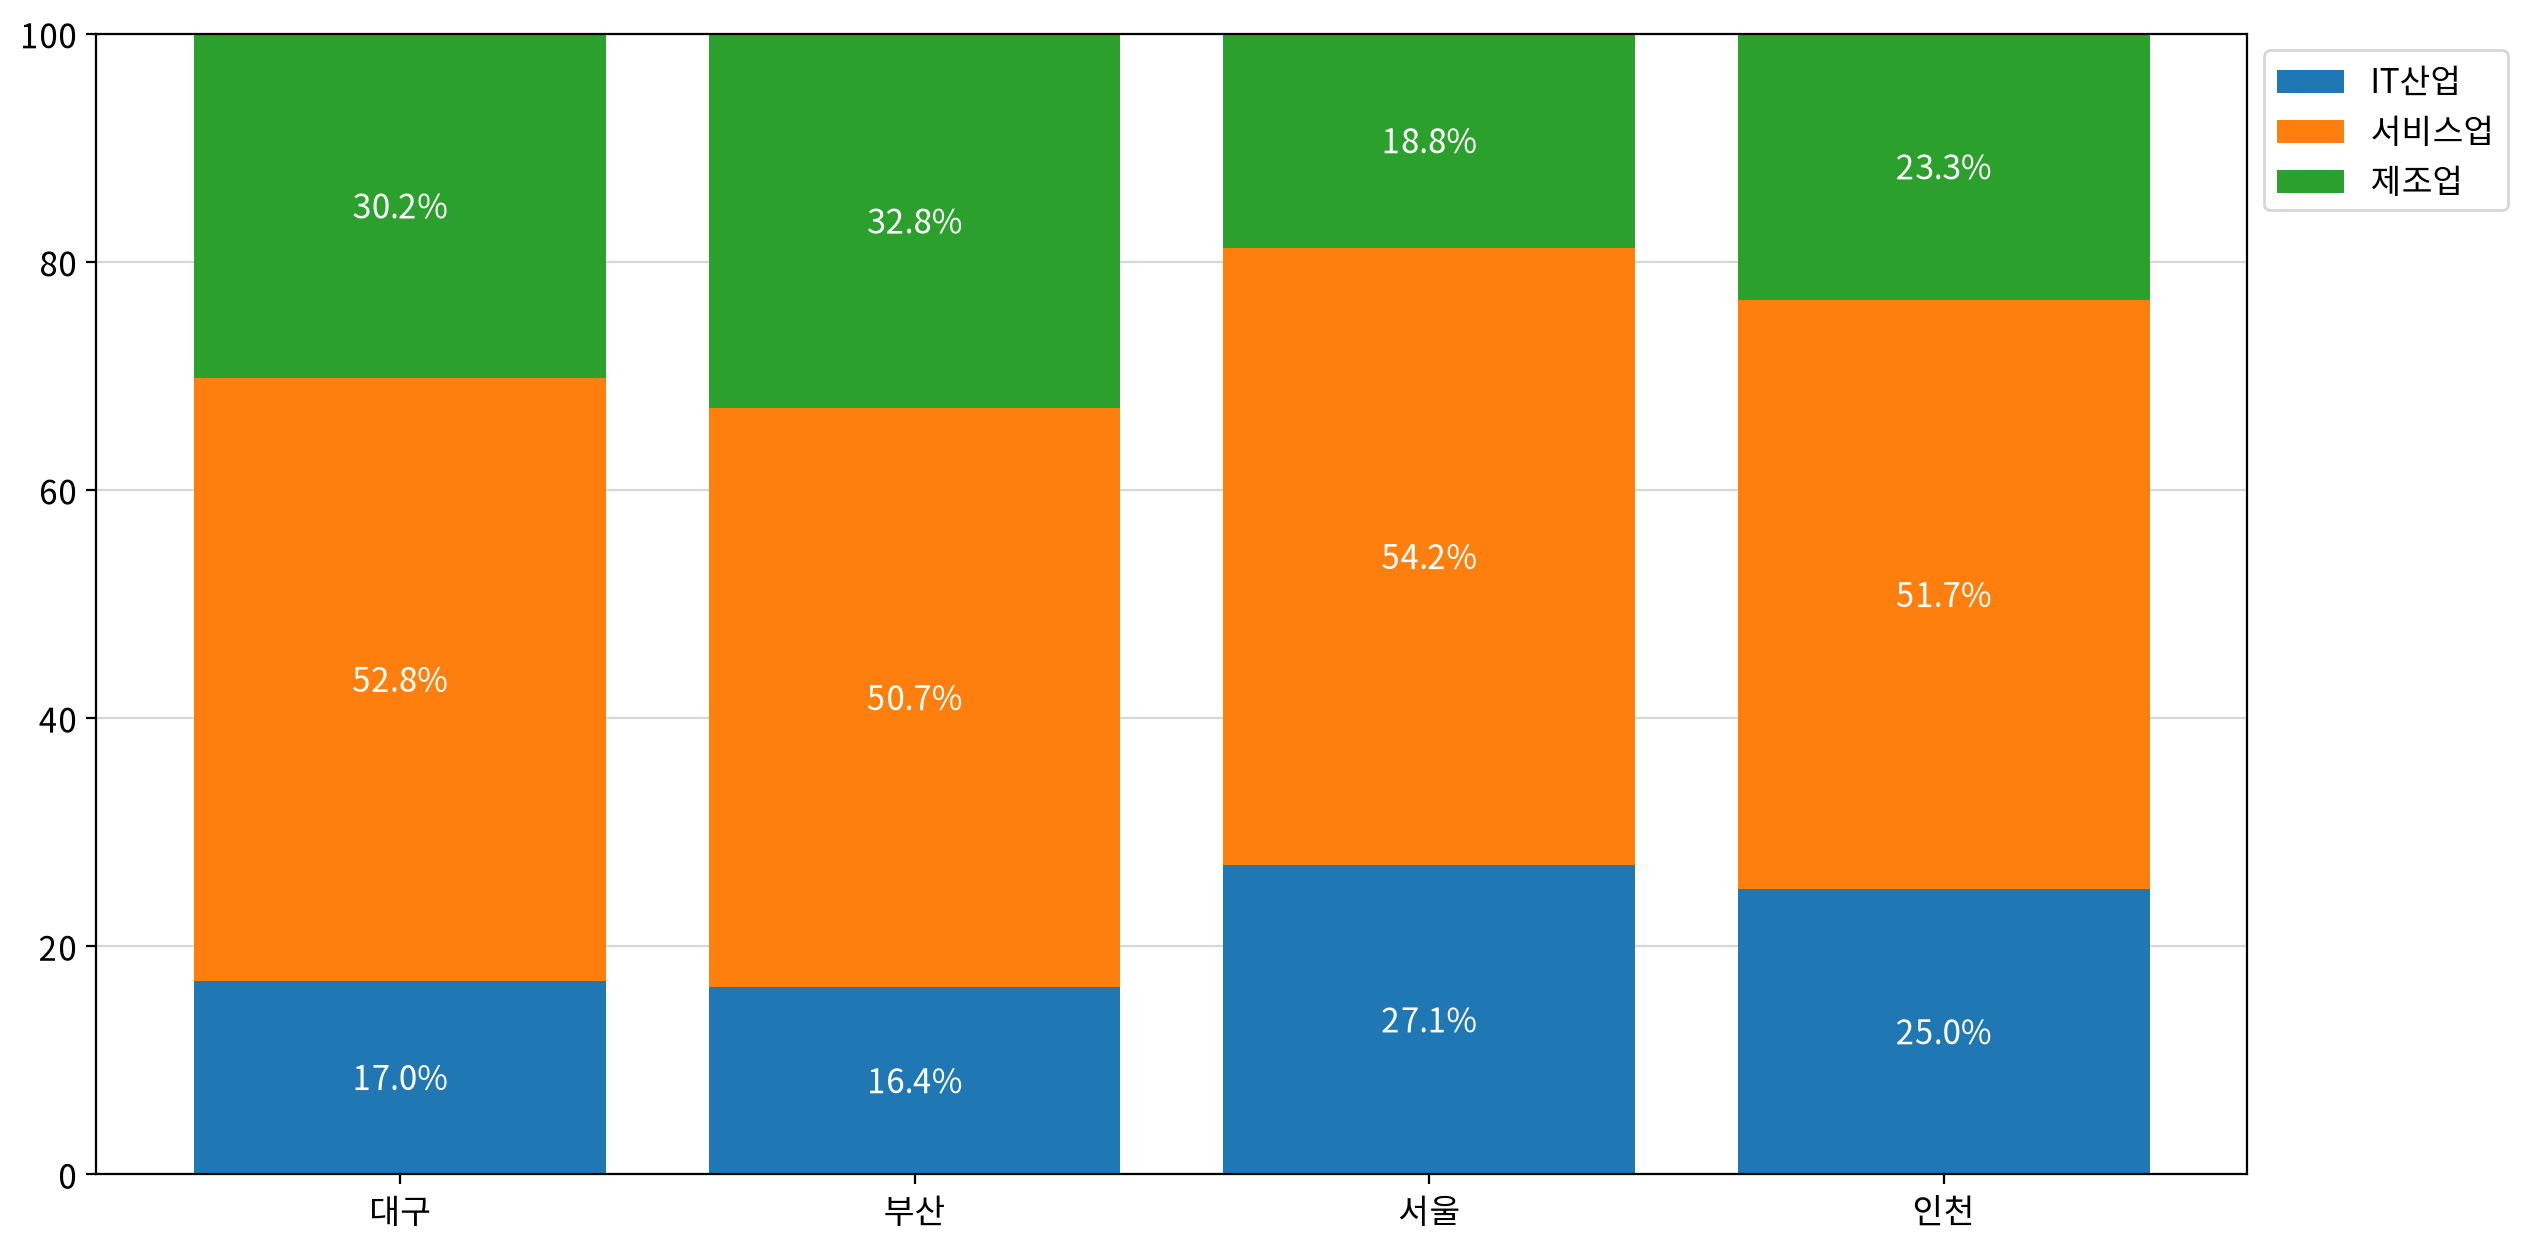

In [6]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.bar(df.index, df['제조업'], bottom=df['IT산업'] + df['서비스업'], label='제조업')

# 기본 막대 그래프, 서비스업 누적 막대 그래프, 제조업 누적 막대 그래프에 대한 범례 추가
ax.legend(bbox_to_anchor=(1, 1))

# y축 범위를 0에서 100으로 설정
ax.set_ylim(0, 100)

# 텍스트 형식
text_format = '{:.1f}%'

# 각 막대 위에 종사자 수 표시
for i in df.index:
    ax.text(x=i, y=df['IT산업'][i] / 2, 
            s=text_format.format(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['IT산업'][i] + df['서비스업'][i] / 2, 
            s=text_format.format(df['서비스업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['IT산업'][i] + df['서비스업'][i] + df['제조업'][i] / 2, 
            s=text_format.format(df['제조업'][i]), 
            ha='center', va='center', color='white', fontsize=12)

my_plot.show()

#### 💡 인사이트

- 📌 모든 지역에서 서비스업 비율이 가장 큼.
- 🥇 서비스업 비율 순위는 서울 54.2% > 대구 52.8% > 인천 51.7% > 부산 50.7%임.
- 💻 IT산업 비율은 서울 27.1%가 가장 높고, 인천 25.0%, 대구 17.0%, 부산 16.4% 순임.
- 🏭 제조업 비율은 부산 32.8%가 가장 높고, 대구 30.2%, 인천 23.3%, 서울 18.8% 순임.
- 🔍 서울은 IT산업 비율(27.1%)이 4개 지역 중 가장 높은 반면, 제조업 비율(18.8%)은 가장 낮음.
- 📊 부산은 IT산업 비율(16.4%)이 가장 낮고, 제조업 비율(32.8%)은 가장 높아 산업 비중 분포가 다른 지역과 대비됨.

## #03. 팔레트를 적용한 가로 분할 막대 그래프

### 1. seaborn의 팔레트에서 범주의 종류 수 만큼 색상 추출

In [7]:
# seaborn의 pastel color palette 사용
colors = sb.color_palette("Set2", 3)
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549)]

### 2. 가로 분할 막대 그래프

- `bottom`이 아닌 `left`를 사용한다.
- 색상을 적용하고 y축이 아닌 x축의 범위를 0~100으로 조절한다.
- 텍스트 출력의 x좌표와 y좌표를 서로 바꿔서 지정하고 출력 형식을 적용한다.

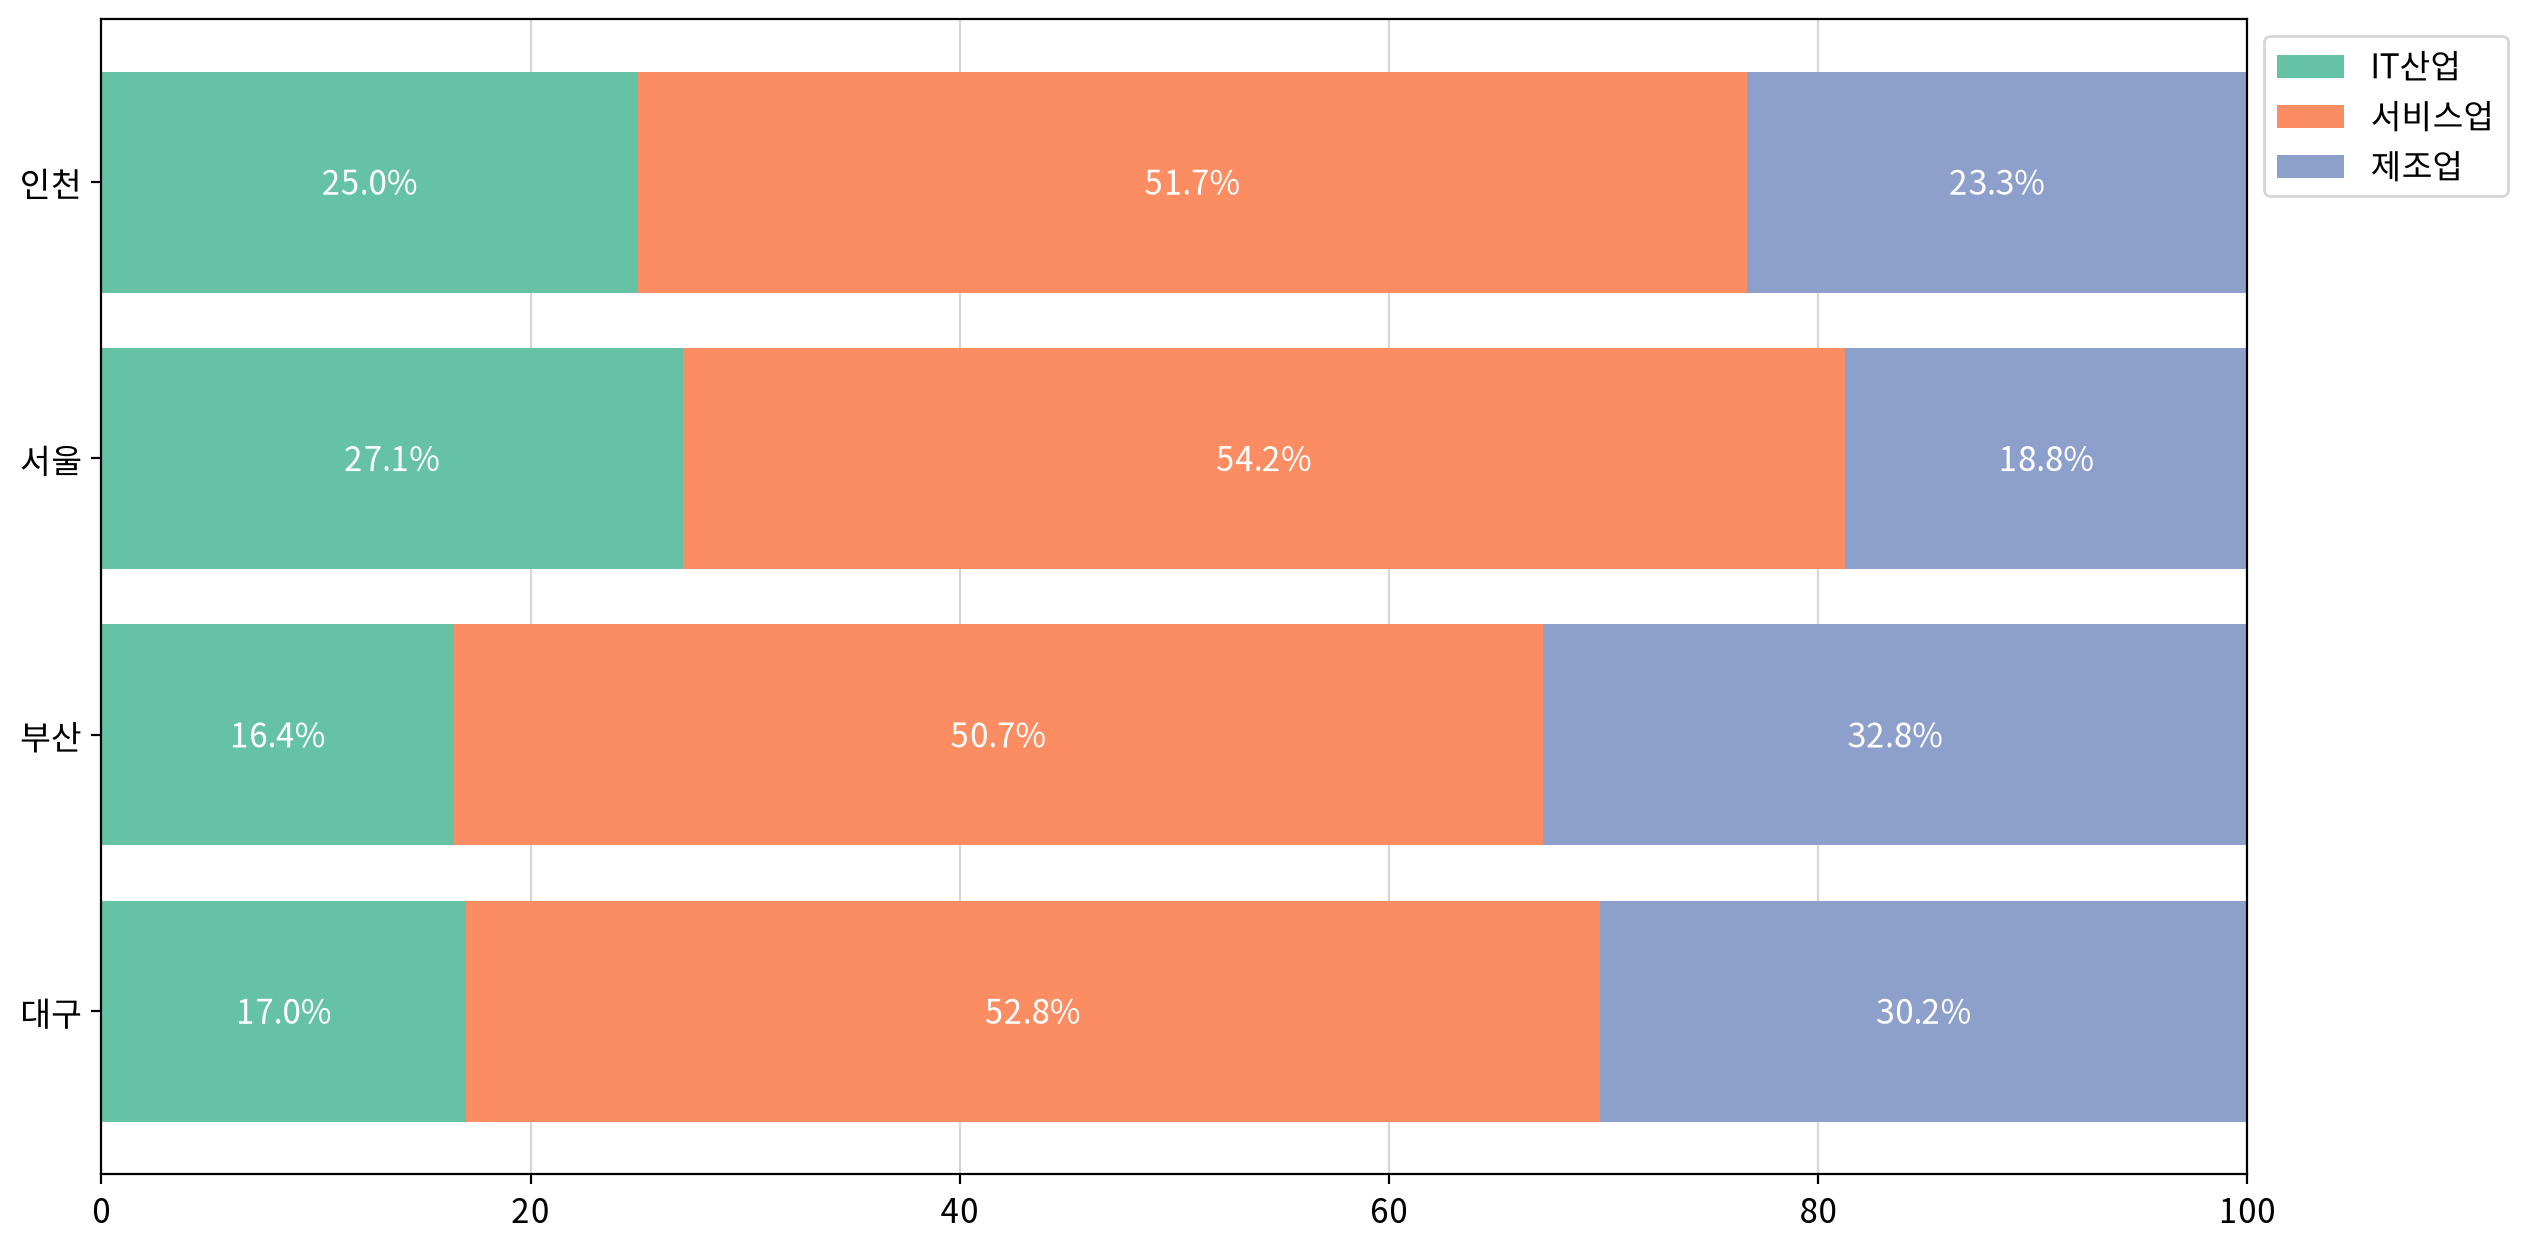

In [8]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.barh(df.index, df['IT산업'], label='IT산업', color=colors[0])

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.barh(df.index, df['서비스업'], left=df['IT산업'], label='서비스업', color=colors[1])

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.barh(df.index, df['제조업'], left=df['IT산업'] + df['서비스업'], 
        label='제조업', color=colors[2])

# 기본 막대 그래프, 서비스업 누적 막대 그래프, 제조업 누적 막대 그래프에 대한 범례 추가
ax.legend(bbox_to_anchor=(1, 1))

# x축 범위를 0에서 100으로 설정
ax.set_xlim(0, 100)

# 텍스트 형식
text_format = '{:.1f}%'

# 각 막대 위에 종사자 수 표시
for i in df.index:
    ax.text(x=df['IT산업'][i] / 2, y=i, 
            s=text_format.format(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=df['IT산업'][i] + df['서비스업'][i] / 2, y=i, 
            s=text_format.format(df['서비스업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=df['IT산업'][i] + df['서비스업'][i] + df['제조업'][i] / 2, y=i, 
            s=text_format.format(df['제조업'][i]), 
            ha='center', va='center', color='white', fontsize=12)

my_plot.show()

## #04. 모듈화 기능 확인

### 비율 분할 막대 그래프

/Users/leekh/hossam-ml/helpers/my_plot.py:589: FutureWarning: The provided callable <function sum at 0x10af0c220> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df = pivot_table(data=data, index=x, values=y, columns=hue, aggfunc=aggfunc, fill_value=0)


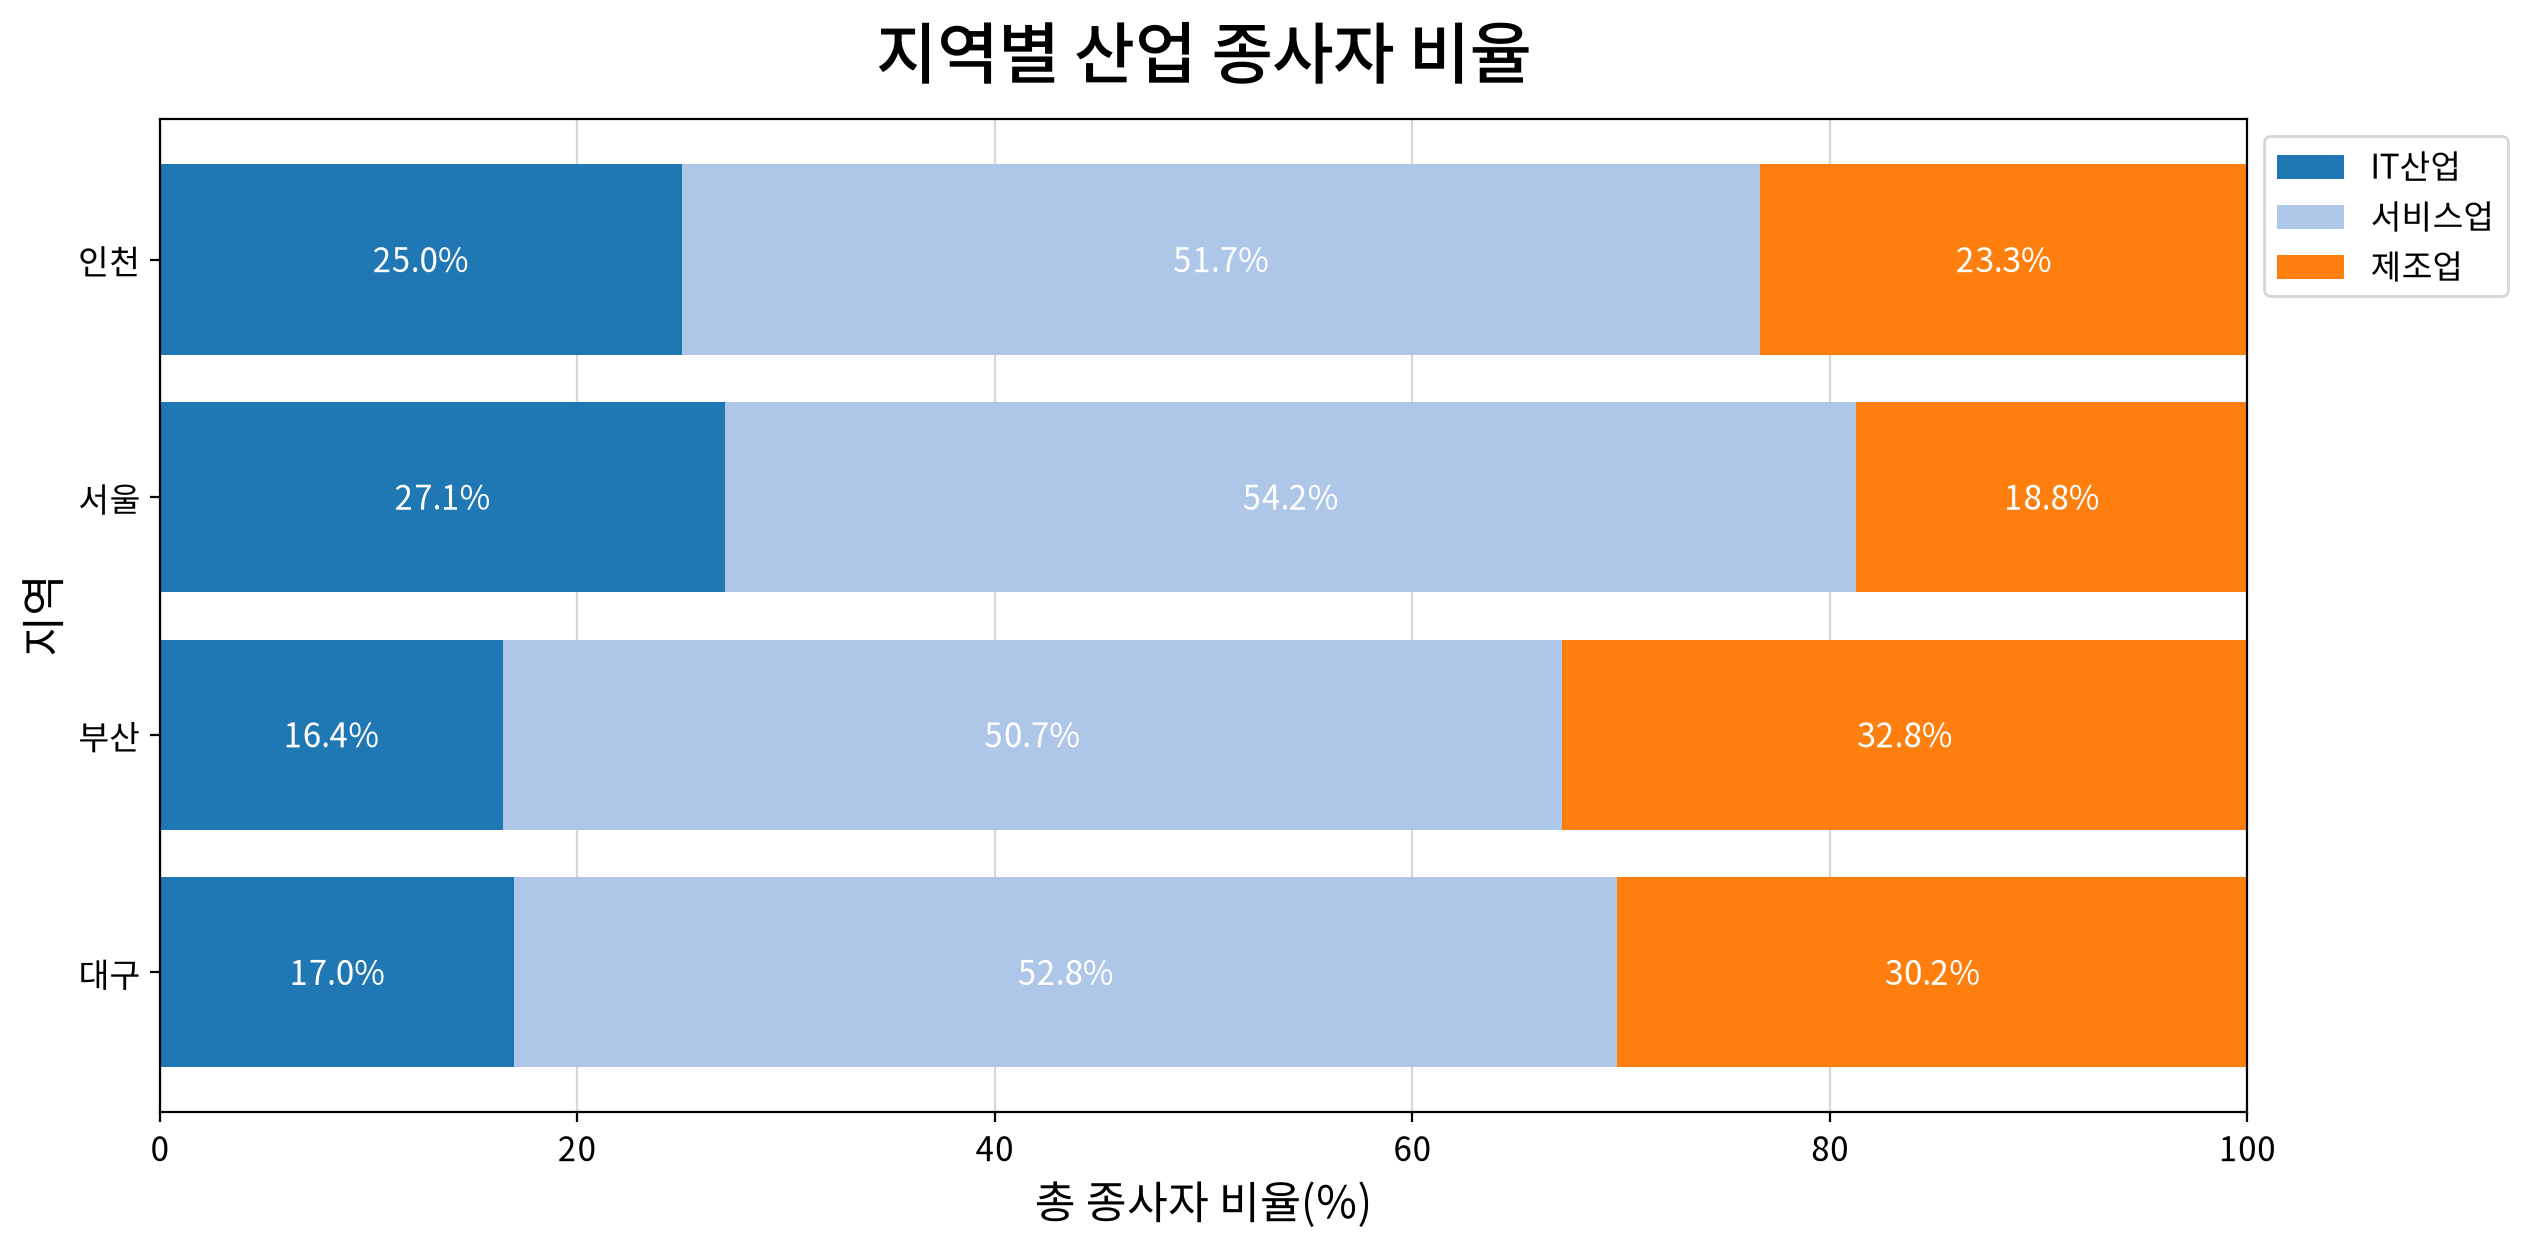

In [9]:
my_plot.stackplot(data=origin, x="지역", y="종사자 수", hue="산업", 
                  aggfunc=np.sum, orient='h', ratio=True, palette="tab20",
                  title="지역별 산업 종사자 비율", xlabel="총 종사자 비율(%)", ylabel="지역")